# Simulation Evaluation
**Simulation Period:** 2016-05-17 → 2016-05-31 (14 days)

## Evaluation Overview

This notebook evaluates the **Advanced Router** simulation against the real BPI 2017 event log, and compares multiple resource allocation configurations. The decision to use the Advanced Router (C4.5 decision trees) was established in `simulation_evaluation/decision_evaluation/`.

### Evaluation Flow

| Phase | Comparison | Goal |
|---|---|---|
| **Phase 2** | Advanced Router vs Real Log | Assess simulation fidelity |
| **Phase 4** | All Allocation Configs vs Real Log | Select best resource allocation method |

### Metrics

| # | Metric | Definition | Direction |
|---|--------|------------|-----------|
| 1 | **Average Cycle Time** | Mean wall-clock time per case | ↓ lower is better |
| 2 | **Average Resource Occupation** | Mean fraction of shift time spent working | ↑ higher is better |
| 3 | **(Weighted) Resource Fairness (MAD)** | Mean absolute deviation from average occupation | ↓ lower is better |
| 4 | **Outcome Distribution Fidelity** | 1 − JSD between simulated and real outcome distributions | ↑ higher is better |

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import datetime
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11

RESULTS_DIR = Path('results')
RESULTS_DIR.mkdir(exist_ok=True)

BASE = Path('..')
COLORS = {'advanced': "#DD528A"}

# Simulation period constants (14-day window)
SIM_START = datetime.date(2016, 5, 17)
SIM_END   = datetime.date(2016, 5, 31)
DAY_ZERO  = datetime.date(2016, 1, 1)   # DayId=0 anchor

# Only Workflow activities have explicit start/complete pairs
W_ACTIVITIES = [
    'W_Call after offers',
    'W_Call incomplete files',
    'W_Complete application',
    'W_Handle leads',
    'W_Validate application',
]

## Simulation Settings

| Component | Setting | File |
|---|---|---|
| **Decision Router** | `"advanced"` — C4.5 decision trees trained on real log | `decision_analysis/DPManager.py` |
| **Resource Allocator** | Per-config: shortest_queue / advanced_local / advanced_global | `resources/ResourceAllocator.py` |
| **Availability Schedule** | Shift-based, 140 resources | `availabilities_advanced.csv` |
| **Role Permissions** | Role-based activity gating | `role_permissions.csv` |
| **Processing Time Model** | QR model (`pt_use_qr=True`) | `Advanced_Model/proc_qr_bundle.joblib` |
| **Arrival Model** | `AdvancedSpawner` with NL holidays | `spawn_rates/` |
| **Simulation window** | 2016-05-17 09:15 → 2016-05-31 (14 days) | — |
| **Replications** | 5 per allocation config | — |

The routing strategy (Advanced Router) was selected based on the analysis in `simulation_evaluation/decision_evaluation/`.

## Data Loading

## Simulation Production

Runs each allocation config (if CSVs don't exist yet) and saves results to `simulation_evaluation/resource_allocation/data/<config>/run_NN.csv`.  
**Skip this section** if CSVs are already present — the run loop checks before executing.

| Config | Method | delta | max_events | Rationale |
|---|---|---|---|---|
| `shortest_queue` | SHORTEST_QUEUE | — | 300k | Baseline, no RETRY |
| `advanced_local_d5` | ADVANCED_LOCAL | 5 | 600k | Existing working config |
| `advanced_global_d100` | ADVANCED_GLOBAL | 100 | 1M | High delta avoids RETRY cascade |

**Horizon:** 14 simulated calendar days (2016-05-17 → 2016-05-31), 5 replications per config.

In [26]:
import sys
from pathlib import Path

_PROJECT_ROOT = Path("..").resolve()
if str(_PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(_PROJECT_ROOT))

import resources.ResourceAllocator as ra
from decision_analysis.DPManager import DPManager
from resources.ResourceManager import ResourceManager
from sim_core.engine import Engine
from sim_core.pn_model import wrap_net
from sim_core.bpmn_io import read_bpmn
from spawn_rates import AdvancedSpawner, get_rate_table, get_holidays
from processing_times.sampling import ProcessingTimeSampler

_SIM_START = datetime.datetime(2016, 5, 17, 9, 15, 0)
_SIM_END   = _SIM_START + datetime.timedelta(days=14)
N_RUNS     = 5

EVAL_CONFIGS = {
    "shortest_queue":       {"method": ra.Methods.SHORTEST_QUEUE, "delta": 1,   "max_events": 300_000},
    "advanced_local_d5":    {"method": ra.Methods.ADVANCED_LOCAL,  "delta": 5,   "max_events": 600_000},
    "advanced_global_d100": {"method": ra.Methods.ADVANCED_GLOBAL, "delta": 100, "max_events": 1_000_000},
}
print("Simulation configs loaded:", list(EVAL_CONFIGS.keys()))

Simulation configs loaded: ['shortest_queue', 'advanced_local_d5', 'advanced_global_d100']


In [27]:
_BPMN_PATH  = BASE / "data" / "process_model.bpmn"
_RULES_PATH = BASE / "decision_analysis" / "decision_prob_rules.json"
_BRAIN_PATH = BASE / "decision_analysis" / "simulation_brain.pkl"
_PROC_JSON  = BASE / "processing_times" / "Basic_Models" / "processing_models_proc.json"
_TOTAL_JSON = BASE / "processing_times" / "Basic_Models" / "processing_models_full_dur.json"
_WAIT_JSON  = BASE / "processing_times" / "Basic_Models" / "wait_reference.json"

def build_engine(method, delta, seed):
    bpmn_net, im, fm = read_bpmn(str(_BPMN_PATH))
    pn_model   = wrap_net(bpmn_net, im, fm)
    holidays   = get_holidays()
    rate_table = get_rate_table(holidays)
    spawner    = AdvancedSpawner(rate_table=rate_table, holidays=holidays, seed=seed)
    res_mgr    = ResourceManager(
        permissions="role_permissions.csv",
        availabilities="availabilities_advanced.csv",
        method=method,
        delta=delta,
        batch_k=5,
    )
    dp_mgr = DPManager(
        pn=pn_model,
        mode="advanced",
        rules_path=str(_RULES_PATH),
        model_path=str(_BRAIN_PATH),
    )
    pt = ProcessingTimeSampler.from_paths(
        proc_json=str(_PROC_JSON),
        total_json=str(_TOTAL_JSON),
        wait_json=str(_WAIT_JSON),
        seed=seed,
        default_value=60.0,
    )
    return Engine(
        pn=pn_model,
        spawner=spawner,
        resource_manager=res_mgr,
        decision_manager=dp_mgr,
        pt_sampler=pt,
        start_time=_SIM_START,
        pt_use_qr=True,
    )

In [28]:
_OUT_ROOT = BASE / "simulation_evaluation" / "resource_allocation" / "data"

for _cfg_name, _cfg in EVAL_CONFIGS.items():
    _out_dir = _OUT_ROOT / _cfg_name
    _out_dir.mkdir(parents=True, exist_ok=True)
    for _run_idx in range(N_RUNS):
        _out_path = _out_dir / f"run_{_run_idx:02d}.csv"
        if _out_path.exists():
            print(f"[skip] {_cfg_name}  run {_run_idx:02d}  →  {_out_path.name}")
            continue
        _seed = abs(hash(_cfg_name)) % 10_000 + _run_idx
        print(f"\n[{_cfg_name}] run {_run_idx:02d}  seed={_seed}", flush=True)
        _engine = build_engine(_cfg["method"], _cfg["delta"], _seed)
        _engine.spawn()
        _engine.run(max_events=_cfg["max_events"], end_time=_SIM_END)
        pd.DataFrame(_engine.log).to_csv(_out_path, index=False)
        print(f"  → saved {len(_engine.log):,} rows  →  {_out_path.name}", flush=True)

print("\nAll simulation runs complete.")

[skip] shortest_queue  run 00  →  run_00.csv
[skip] shortest_queue  run 01  →  run_01.csv
[skip] shortest_queue  run 02  →  run_02.csv
[skip] shortest_queue  run 03  →  run_03.csv
[skip] shortest_queue  run 04  →  run_04.csv
[skip] advanced_local_d5  run 00  →  run_00.csv
[skip] advanced_local_d5  run 01  →  run_01.csv
[skip] advanced_local_d5  run 02  →  run_02.csv
[skip] advanced_local_d5  run 03  →  run_03.csv
[skip] advanced_local_d5  run 04  →  run_04.csv
[skip] advanced_global_d100  run 00  →  run_00.csv
[skip] advanced_global_d100  run 01  →  run_01.csv
[skip] advanced_global_d100  run 02  →  run_02.csv
[skip] advanced_global_d100  run 03  →  run_03.csv
[skip] advanced_global_d100  run 04  →  run_04.csv

All simulation runs complete.


In [32]:
# Simulation event log — Advanced Router
advanced_log = pd.read_csv(BASE / 'decision_analysis/sim_output_advanced.csv',
                           parse_dates=['time:timestamp'])

# Resource schedules
avail_df = pd.read_csv(BASE / 'resources/availabilities/availabilities_advanced.csv')
avail_df['StartTime']   = pd.to_datetime(avail_df['StartTime'],   format='%H:%M:%S').dt.time
avail_df['EndTime']     = pd.to_datetime(avail_df['EndTime'],     format='%H:%M:%S').dt.time
avail_df['DurationMin'] = avail_df['DurationMin'].fillna(0).astype(int)

# Role assignments
roles_df   = pd.read_csv(BASE / 'resources/permissions/resource_roles.csv')
role_perms = pd.read_csv(BASE / 'resources/permissions/role_permissions.csv')

print(f"Advanced log: {len(advanced_log):>6,} events | {advanced_log['case:concept:name'].nunique():>4} cases")
print(f"Simulation  : {advanced_log['time:timestamp'].min().date()} -> {advanced_log['time:timestamp'].max().date()}")
print(f"Resources in schedule: {avail_df['Resource'].nunique()}")

Basic log   : 96,669 events | 1981 cases
Advanced log: 96,591 events | 2018 cases
Simulation  : 2016-05-17 -> 2016-06-03
Resources in schedule: 140


In [30]:
SIM_DATA_ROOT = BASE / "simulation_evaluation" / "resource_allocation" / "data"

_CONFIG_DIRS = {
    "shortest_queue":       SIM_DATA_ROOT / "shortest_queue",
    "advanced_local_d5":    SIM_DATA_ROOT / "advanced_local_d5",
    "advanced_global_d100": SIM_DATA_ROOT / "advanced_global_d100",
}

def load_config_runs(config_dir):
    """Concatenate all run_NN.csv files for one config into a single DataFrame."""
    files = sorted(config_dir.glob("run_*.csv"))
    if not files:
        return pd.DataFrame()
    return pd.concat(
        [pd.read_csv(f, parse_dates=["time:timestamp"]) for f in files],
        ignore_index=True,
    )

config_logs = {name: load_config_runs(path) for name, path in _CONFIG_DIRS.items()}
for name, df in config_logs.items():
    print(f"  {name}: {len(df):,} rows, {df['case:concept:name'].nunique() if not df.empty else 0} cases")

  shortest_queue: 472,570 rows, 2020 cases
  advanced_local_d5: 84,531 rows, 720 cases
  advanced_global_d100: 357,792 rows, 1557 cases


## Helper Functions

In [33]:
# Metric helpers
def compute_cycle_times(df):
    """Return Series of per-case cycle time in hours."""
    ct = df.groupby('case:concept:name')['time:timestamp'].agg(['min', 'max'])
    return (ct['max'] - ct['min']).dt.total_seconds() / 3600


def compute_working_seconds(df):
    """
    Compute total working seconds per resource.
    Only W_* activities carry explicit start/complete pairs;
    Application (A_*) and Offer (O_*) events are instantaneous.
    """
    w = df[df['concept:name'].isin(W_ACTIVITIES)].copy()
    starts    = (w[w['lifecycle:transition'] == 'start']
                 [['case:concept:name', 'concept:name', 'org:resource', 'time:timestamp']]
                 .rename(columns={'time:timestamp': 'start_time'}))
    completes = (w[w['lifecycle:transition'] == 'complete']
                 [['case:concept:name', 'concept:name', 'org:resource', 'time:timestamp']]
                 .rename(columns={'time:timestamp': 'end_time'}))
    merged = pd.merge(starts, completes,
                      on=['case:concept:name', 'concept:name', 'org:resource'])
    merged['working_seconds'] = (
        (merged['end_time'] - merged['start_time'])
        .dt.total_seconds()
        .clip(lower=0)
    )
    return merged.groupby('org:resource')['working_seconds'].sum()


def compute_available_seconds(avail_df, start_date=SIM_START, end_date=SIM_END):
    """
    Compute total scheduled (available) seconds per resource
    across every day in [start_date, end_date], inclusive.
    DayId is defined as (date - 2016-01-01).days % 7
    """
    result = {}
    for resource, grp in avail_df.groupby('Resource'):
        total = 0.0
        day = start_date
        while day <= end_date:
            day_id = (day - DAY_ZERO).days % 7
            row = grp[grp['DayId'] == day_id]
            if not row.empty:
                r = row.iloc[0]
                shift_s = datetime.datetime.combine(day, r['StartTime'])
                shift_e = datetime.datetime.combine(day, r['EndTime'])
                secs = max(0.0, (shift_e - shift_s).total_seconds() - r['DurationMin'] * 60)
                total += secs
            day += datetime.timedelta(days=1)
        result[resource] = total
    return pd.Series(result, name='available_seconds')


def compute_occupation(working_s, available_s):
    """Return DataFrame with working, available, and occupation columns."""
    df = pd.DataFrame({'working_seconds': working_s,
                       'available_seconds': available_s})
    df['working_seconds'] = df['working_seconds'].fillna(0)
    df = df[df['available_seconds'] > 0].copy()
    df['occupation'] = (df['working_seconds'] / df['available_seconds']).clip(0, 1)
    return df


def fairness_metrics(occ_series, avail_seconds=None):
    """
    Returns:
      mean_occ   – mean occupation
      mad        – unweighted mean absolute deviation (lower -> fairer)
      wmad       – weighted MAD (weight = available_seconds fraction)
    """
    mean_occ = occ_series.mean()
    mad = (occ_series - mean_occ).abs().mean()
    if avail_seconds is not None:
        w = avail_seconds / avail_seconds.sum()
        wmad = (w * (occ_series - mean_occ).abs()).sum()
    else:
        wmad = np.nan
    return mean_occ, mad, wmad


In [33]:
import pm4py

# Load full real log.
# No period filtering for cycle time: filtering to cases completing within the
# simulation window retains only the fastest ~1 % of real cases (severe bias).
real_raw = pm4py.read_xes(str(BASE / 'data/BPI Challenge 2017.xes.gz'))
real_df  = pm4py.convert_to_dataframe(real_raw)
real_df['time:timestamp'] = pd.to_datetime(real_df['time:timestamp'], utc=True).dt.tz_localize(None)

real_log = real_df.copy()
real_ct  = compute_cycle_times(real_log)

n_real_cases = real_log['case:concept:name'].nunique()
print(f"Real log — {n_real_cases:,} cases, {len(real_log):,} events")
print(f"Avg CT real (full log): {real_ct.mean():.2f} h  ({real_ct.mean()/24:.1f} days)")


parsing log, completed traces :: 100%|██████████| 31509/31509 [00:19<00:00, 1597.60it/s]


Real log — 31,509 cases, 1,202,267 events
Avg CT real (full log): 525.59 h  (21.9 days)


In [34]:
REAL_COLOR = '#2ECC71'

# Complete-lifecycle events only (real log)
real_complete = (real_log[real_log['lifecycle:transition'].str.lower() == 'complete'].copy()
                 if 'lifecycle:transition' in real_log.columns else real_log.copy())

# Real log resource occupation (sim period only)
SIM_START_DT = pd.Timestamp('2016-05-17')
SIM_END_DT   = pd.Timestamp('2016-05-23')

real_w = real_df[
    real_df['concept:name'].isin(W_ACTIVITIES) &
    (real_df['time:timestamp'] >= SIM_START_DT) &
    (real_df['time:timestamp'] <  SIM_END_DT)
].copy()

r_starts    = (real_w[real_w['lifecycle:transition'].str.lower() == 'start']
               [['case:concept:name','concept:name','org:resource','time:timestamp']]
               .rename(columns={'time:timestamp':'start_time'}))
r_completes = (real_w[real_w['lifecycle:transition'].str.lower() == 'complete']
               [['case:concept:name','concept:name','org:resource','time:timestamp']]
               .rename(columns={'time:timestamp':'end_time'}))
real_pairs = pd.merge(r_starts, r_completes, on=['case:concept:name','concept:name','org:resource'])
real_pairs['working_seconds'] = (
    (real_pairs['end_time'] - real_pairs['start_time'])
    .dt.total_seconds().clip(lower=0)
)
real_work_period = real_pairs.groupby('org:resource')['working_seconds'].sum()

available = compute_available_seconds(avail_df)
real_occ_period = compute_occupation(real_work_period, available)
r_mean, r_mad, r_wmad = fairness_metrics(
    real_occ_period['occupation'], real_occ_period['available_seconds'])

print(f"Real log period W_ pairs: {len(real_pairs):,}  |  active resources: {len(real_work_period)}")
print(f"Real occupation: {r_mean*100:.2f}%   MAD: {r_mad:.4f}   wMAD: {r_wmad:.4f}")


Real log period W_ pairs: 236  |  active resources: 54
Real occupation: 2.25%   MAD: 0.0371   wMAD: 0.0399


## Metric Computation

All metrics are computed here for Basic Router, Advanced Router, and the Real Log.
Phase 1–3 sections below visualise the results by comparison group.


## Metric 1 – Average Cycle Time

**Definition:** The cycle time of a process instance is the elapsed wall-clock time from the moment the first event of that case is recorded until its last event.  
$$\overline{CT} = \frac{1}{|\mathcal{C}|} \sum_{c \in \mathcal{C}} (t^{\max}_c - t^{\min}_c)$$

A lower average cycle time means cases are completed faster -> a direct indicator of process efficiency.

In [34]:
# Filter to completed cases (> 2 events) before computing cycle time.
# Right-censored cases (spawned near end of simulation window) have only
# 2 events and a cycle time of ~0 h, pulling the median to 0 and distorting
# the mean. Completed cases give a meaningful cycle time distribution.
advanced_completed_ct = advanced_log[advanced_log['case:concept:name'].isin(
    advanced_log.groupby('case:concept:name').size()[lambda s: s > 2].index)]

advanced_ct = compute_cycle_times(advanced_completed_ct)
n_adv_comp  = len(advanced_ct)

print(f"Completed cases used for cycle time:")
print(f"  Advanced: {n_adv_comp} / {advanced_log['case:concept:name'].nunique()}"
      f" ({n_adv_comp/advanced_log['case:concept:name'].nunique()*100:.1f}%)")
print()

ct_summary = pd.DataFrame({
    'Mean (h)':    [advanced_ct.mean()],
    'Median (h)':  [advanced_ct.median()],
    'Std (h)':     [advanced_ct.std()],
    'Min (h)':     [advanced_ct.min()],
    'Max (h)':     [advanced_ct.max()],
    'Mean (days)': [advanced_ct.mean() / 24],
}, index=['Advanced Router'])

print('METRIC 1: AVERAGE CYCLE TIME (completed cases only)')
print(ct_summary.round(2).to_string())

Completed cases used for cycle time:
  Basic   : 1981 / 1981 (100.0%)
  Advanced: 2018 / 2018 (100.0%)

METRIC 1: AVERAGE CYCLE TIME (completed cases only)
                 Mean (h)  Median (h)  Std (h)  Min (h)  Max (h)  Mean (days)
Basic Router         9.83        4.37    10.60     0.11    61.17         0.41
Advanced Router      9.71        5.25    10.16     0.16    48.92         0.40


## Metric 2 – Average Resource Occupation

**Definition:** For each resource $r$, occupation is the fraction of scheduled working time actually spent executing tasks:
$$\text{occ}(r) = \frac{\sum_{e\,:\,\text{resource}=r} (t^{\text{complete}}_e - t^{\text{start}}_e)}{\text{AvailableTime}(r)}$$

The **Average Resource Occupation** is the mean over all resources:  
$$\overline{\text{occ}} = \frac{1}{|\mathcal{R}|}\sum_{r \in \mathcal{R}} \text{occ}(r)$$

> **Note:** Only *Workflow* activities (`W_*`) have explicit `start` / `complete` event pairs in this simulator; Application (`A_*`) and Offer (`O_*`) events are instantaneous and do not contribute to working time.

In [36]:
print('Computing working time per resource...')
advanced_work = compute_working_seconds(advanced_log)

print('Computing available time per resource (iterating over schedule)...')
available = compute_available_seconds(avail_df)

advanced_occ = compute_occupation(advanced_work, available)

occ_summary = pd.DataFrame({
    'Mean Occupation':   [advanced_occ['occupation'].mean()],
    'Median Occupation': [advanced_occ['occupation'].median()],
    'Std':               [advanced_occ['occupation'].std()],
    'Max':               [advanced_occ['occupation'].max()],
    '# Resources':       [len(advanced_occ)],
}, index=['Advanced Router'])

print('\nMETRIC 2: AVERAGE RESOURCE OCCUPATION')
print((occ_summary * [100, 100, 100, 100, 1]).round(2).to_string())
print('(values in % except # Resources)')
print()
print(f"Advanced mean occupation: {advanced_occ['occupation'].mean()*100:.3f}%")

Computing working time per resource...
Computing available time per resource (iterating over schedule)...

METRIC 2: AVERAGE RESOURCE OCCUPATION
                 Mean Occupation  Median Occupation    Std    Max  # Resources
Basic Router               21.23               5.02  32.97  100.0          140
Advanced Router            21.82               4.34  33.80  100.0          140
(values in % except # Resources)

Basic mean occupation: 21.233%
Advanced mean occupation: 21.823%


## Metric 3 – (Weighted) Resource Fairness

**Definition:** Fairness measures how evenly the workload is spread across resources. We use the **Mean Absolute Deviation (MAD)** from the average occupation:

$$\text{Fairness}_{\text{unweighted}} = \frac{1}{|\mathcal{R}|}\sum_{r}|\text{occ}(r) - \overline{\text{occ}}|$$

**Weighted variant** — resources with longer availability periods count more:

$$\text{Fairness}_{\text{weighted}} = \sum_{r} w_r \cdot |\text{occ}(r) - \overline{\text{occ}}|, \quad w_r = \frac{\text{AvailableTime}(r)}{\sum_{r'}\text{AvailableTime}(r')}$$

**Lower = fairer** (smaller deviation = more equal load distribution).

In [38]:
a_mean, a_mad, a_wmad = fairness_metrics(
    advanced_occ['occupation'], advanced_occ['available_seconds'])

def _active_occ(occ_frame, log):
    task_cnt = (
        log[log['lifecycle:transition'] == 'start']
        .groupby('org:resource').size()
    )
    return occ_frame[occ_frame.index.isin(task_cnt[task_cnt > 0].index)]

a_occ_active = _active_occ(advanced_occ, advanced_log)
_, a_mad_act, a_wmad_act = fairness_metrics(
    a_occ_active['occupation'], a_occ_active['available_seconds'])

fairness_summary = pd.DataFrame({
    'Mean Occupation':               [a_mean],
    'MAD (unweighted, all)':         [a_mad],
    'MAD (weighted, all)':           [a_wmad],
    'MAD (unweighted, active only)': [a_mad_act],
    'MAD (weighted, active only)':   [a_wmad_act],
    'Fairness Score (1-MAD, all)':   [1 - a_mad],
}, index=['Advanced Router'])

print('METRIC 3: RESOURCE FAIRNESS')
print(fairness_summary.round(5).to_string())
print()
print('Interpretation: Lower MAD = fairer workload distribution')
print(f"  Advanced – all: {a_mad:.5f} / {a_wmad:.5f}  |  active only: {a_mad_act:.5f} / {a_wmad_act:.5f}")
print(f"  (Active-only excludes {len(advanced_occ) - len(a_occ_active)} resources with zero tasks)")

METRIC 3: RESOURCE FAIRNESS
                 Mean Occupation  MAD (unweighted, all)  MAD (weighted, all)  MAD (unweighted, active only)  MAD (weighted, active only)  Fairness Score (1-MAD, all)
Advanced Router             0.14                0.16989              0.17791                        0.20011                      0.20896                      0.83011

Interpretation: Lower MAD = fairer workload distribution
  Advanced – all: 0.16989 / 0.17791  |  active only: 0.20011 / 0.20896
  (Active-only excludes 32 resources with zero tasks)


## Metric 4 – Outcome Distribution Fidelity

**Definition:** Each case is classified into one of six outcome categories based on which terminal activities appear in its trace. Priority order reflects the three process paths in BPI 2017:

| Process Path | Terminal activity | Outcome label |
|---|---|---|
| Initiating Process | `A_Complete` | **Complete** |
| Initiating Process (partial) | `A_Accepted` or `O_Accepted` | **Accepted** |
| Pending Process | `A_Denied` | **Denied** |
| Pending Process | `O_Refused` | **Refused** |
| Not Pending / Pending | `A_Cancelled` or `O_Cancelled` | **Cancelled** |
| Pending Process | `A_Pending` | **Pending** |
| — | none of the above | **Other** |

The fidelity score:

$$\text{Outcome Fidelity} = 1 - \text{JSD}(P_{\text{real}},\, P_{\text{sim}})$$

**Higher fidelity (lower JSD)** → routing decisions lead to realistic process outcomes. Reference is the real log **filtered to terminal cases only** (cases whose last activity is a known outcome activity), excluding right-censored cases still in-flight at observation cutoff.

METRIC 4: OUTCOME DISTRIBUTION FIDELITY
  Real reference : 26,485 terminal cases / 31,509 total (84.1%)
  Adv terminal   : 638 / 651

  Outcome  Real (%)  Advanced (%)
Cancelled      53.5          72.6
  Pending      38.8          16.9
  Refused       7.5          10.3
 Complete       0.1           0.0
 Accepted       0.0           0.2
   Denied       0.1           0.0
    Other       0.0           0.0

  JSD vs real — Advanced: 0.1781
  Fidelity       — Advanced: 0.8219


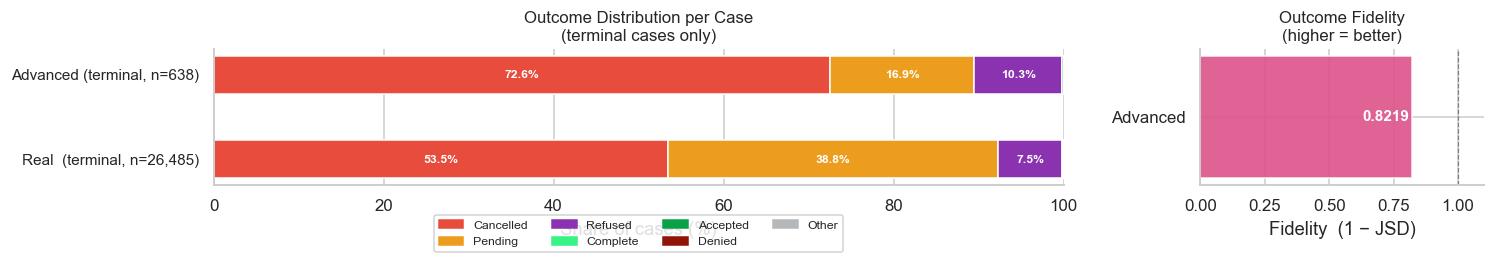

Saved -> results/metric4_outcome_fidelity.png


In [39]:
from scipy.spatial.distance import jensenshannon

OUTCOME_CATEGORIES = ['Cancelled', 'Pending', 'Refused', 'Complete', 'Accepted', 'Denied', 'Other']

OUTCOME_COLORS = {
    'Cancelled': '#E74C3C',
    'Pending':   "#ED9D1D",
    'Refused':   "#8B32B1",
    'Complete':  "#37F285",
    'Accepted':  "#09A048",
    'Denied':    "#901508",
    'Other':     "#B5B8BA",
}

_LAST_ACT_OUTCOME = {
    'A_Complete':  'Complete',
    'A_Accepted':  'Accepted',
    'O_Accepted':  'Accepted',
    'A_Denied':    'Denied',
    'O_Refused':   'Refused',
    'A_Cancelled': 'Cancelled',
    'O_Cancelled': 'Cancelled',
    'A_Pending':   'Pending',
}
TERMINAL_ACTS = set(_LAST_ACT_OUTCOME.keys())

def classify_outcomes(df, terminal_filter=True):
    last = (
        df.sort_values('time:timestamp')
          .groupby('case:concept:name')['concept:name']
          .last()
    )
    if terminal_filter:
        last = last[last.isin(TERMINAL_ACTS)]
    return last.map(lambda a: _LAST_ACT_OUTCOME.get(a, 'Other'))

def outcome_dist(series):
    counts = series.value_counts()
    total  = counts.sum()
    return {cat: counts.get(cat, 0) / total for cat in OUTCOME_CATEGORIES}

def jsd_outcomes(p, q):
    pv = np.array([p[k] for k in OUTCOME_CATEGORIES], dtype=float)
    qv = np.array([q[k] for k in OUTCOME_CATEGORIES], dtype=float)
    if pv.sum() > 0: pv /= pv.sum()
    if qv.sum() > 0: qv /= qv.sum()
    return float(jensenshannon(pv, qv))

real_outcomes = classify_outcomes(real_complete,  terminal_filter=True)
adv_outcomes  = classify_outcomes(advanced_log,   terminal_filter=True)

n_real_terminal = len(real_outcomes)
n_adv_terminal  = len(adv_outcomes)
n_real_total    = real_complete['case:concept:name'].nunique()

real_dist_out = outcome_dist(real_outcomes)
adv_dist_out  = outcome_dist(adv_outcomes)

jsd_a      = jsd_outcomes(real_dist_out, adv_dist_out)
fidelity_a = 1 - jsd_a

comp_df = pd.DataFrame({
    'Outcome':      OUTCOME_CATEGORIES,
    'Real (%)':     [real_dist_out[o] * 100 for o in OUTCOME_CATEGORIES],
    'Advanced (%)': [adv_dist_out[o]  * 100 for o in OUTCOME_CATEGORIES],
})
print(f"METRIC 4: OUTCOME DISTRIBUTION FIDELITY")
print(f"  Real reference : {n_real_terminal:,} terminal cases / {n_real_total:,} total ({n_real_terminal/n_real_total*100:.1f}%)")
print(f"  Adv terminal   : {n_adv_terminal:,} / {advanced_log['case:concept:name'].nunique():,}\n")
print(comp_df.round(1).to_string(index=False))
print(f"\n  JSD vs real — Advanced: {jsd_a:.4f}")
print(f"  Fidelity       — Advanced: {fidelity_a:.4f}")

rows = [
    (f'Real  (terminal, n={n_real_terminal:,})', real_dist_out),
    (f'Advanced (terminal, n={n_adv_terminal:,})', adv_dist_out),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 3.0),
                         gridspec_kw={'width_ratios': [3, 1]})

ax = axes[0]
bar_h = 0.45
for i, (label, dist) in enumerate(rows):
    left = 0.0
    for cat in OUTCOME_CATEGORIES:
        val = dist[cat] * 100
        ax.barh(i, val, bar_h, left=left,
                color=OUTCOME_COLORS[cat],
                label=cat if i == 0 else '')
        if val >= 4:
            ax.text(left + val / 2, i, f'{val:.1f}%',
                    ha='center', va='center', fontsize=8,
                    color='white', fontweight='bold')
        left += val

ax.set_yticks(range(len(rows)))
ax.set_yticklabels([r[0] for r in rows], fontsize=10)
ax.set_xlabel('Share of cases (%)')
ax.set_xlim(0, 100)
ax.set_title('Outcome Distribution per Case\n(terminal cases only)', fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
handles = [mpatches.Patch(color=OUTCOME_COLORS[c], label=c) for c in OUTCOME_CATEGORIES]
ax.legend(handles=handles, fontsize=8, ncol=4,
          loc='upper center', bbox_to_anchor=(0.5, -0.18), framealpha=0.85)

ax2 = axes[1]
bars = ax2.barh(['Advanced'], [fidelity_a], color=[COLORS['advanced']], alpha=0.9, height=0.4)
for bar, val in zip(bars, [fidelity_a]):
    ax2.text(val - 0.01, bar.get_y() + bar.get_height() / 2,
             f'{val:.4f}', ha='right', va='center',
             fontsize=10, color='white', fontweight='bold')
ax2.set_xlim(0, 1.1)
ax2.axvline(1.0, color='grey', linestyle='--', lw=0.8)
ax2.set_xlabel('Fidelity  (1 − JSD)')
ax2.set_title('Outcome Fidelity\n(higher = better)', fontsize=11)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout(pad=2.0)
plt.savefig(RESULTS_DIR / 'metric4_outcome_fidelity.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> results/metric4_outcome_fidelity.png')


## Phase 2 — Advanced Router vs Real Log

Comparing the **Advanced Router** (C4.5 decision trees) simulation against the real BPI 2017 event log.


### Validation – Metric 1: Cycle Time vs Real Log

> **Methodological note:** The simulation compresses external waiting times (inter-arrival queuing, manual review delays, overnight gaps) that are present in the real process but not modelled. This means cycle times will never match numerically — the gap is structural, not a simulation error.  
> The **full real log** (31,509 cases) is used to avoid selection bias: filtering to only cases that complete within the 18-day sim window would retain only the fastest ~1% of real cases, making the comparison misleading. Distribution shape and compression ratio are the meaningful indicators here.

### Metric 1 – Cycle Time: Advanced Router vs Real Log

In [ ]:
n_real_ct = len(real_ct)
n_adv_ct  = len(advanced_ct)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: overlapping histograms (clip real log for readability)
ax = axes[0]
clip_h = 2000
ax.hist(real_ct.clip(upper=clip_h), bins=60, alpha=0.65, color=REAL_COLOR,
        density=True, label=f'Real (mean {real_ct.mean():.0f} h, clipped at {clip_h} h, n={n_real_ct:,})')
ax.hist(advanced_ct, bins=40, alpha=0.65, color=COLORS['advanced'],
        density=True, label=f'Advanced sim (mean {advanced_ct.mean():.1f} h, n={n_adv_ct:,})')
ax.axvline(min(real_ct.mean(), clip_h), color=REAL_COLOR,         linestyle='--', lw=1.8)
ax.axvline(advanced_ct.mean(),          color=COLORS['advanced'], linestyle='--', lw=1.8)
ax.set_xlabel('Cycle Time (hours)')
ax.set_ylabel('Density')
ax.set_title('Cycle Time Distribution\nReal (full log) vs Advanced Sim')
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# Right: mean / median bar comparison
ax2 = axes[1]
labels_ct = [f'Real log\n(n={n_real_ct:,})', f'Advanced sim\n(n={n_adv_ct:,})']
means   = [real_ct.mean(),   advanced_ct.mean()]
medians = [real_ct.median(), advanced_ct.median()]
x = np.arange(2)
w = 0.35
bars_m  = ax2.bar(x - w/2, means,   w, color=[REAL_COLOR, COLORS['advanced']], alpha=0.85, label='Mean')
bars_md = ax2.bar(x + w/2, medians, w, color=[REAL_COLOR, COLORS['advanced']], alpha=0.45, label='Median', edgecolor='grey')
ax2.bar_label(bars_m,  fmt='%.1f h', padding=3, fontsize=9)
ax2.bar_label(bars_md, fmt='%.1f h', padding=3, fontsize=9)
ax2.set_xticks(x)
ax2.set_xticklabels(labels_ct, fontsize=9)
ax2.set_ylabel('Hours')
ax2.set_title('Mean & Median Cycle Time\n(note: y-axis scale difference)')
ax2.legend(fontsize=9)
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'validation_cycle_time.png', bbox_inches='tight')
plt.show()
print(f"Real log mean CT  : {real_ct.mean():.2f} h  ({real_ct.mean()/24:.1f} days)")
print(f"Advanced sim mean : {advanced_ct.mean():.2f} h  ({advanced_ct.mean()/24:.2f} days)")
print(f"Compression ratio : {real_ct.mean()/advanced_ct.mean():.0f}×")
print('Saved -> results/validation_cycle_time.png')

### Validation – Metrics 2 & 3: Resource Occupation & Fairness vs Real Log

> **Methodological note:** For resource metrics, filtering by case completion would bias toward fast cases. Instead we use **all W_ `start`/`complete` event pairs whose timestamps fall within the simulation period** (2016-05-17 → 2016-06-04), regardless of whether the case started or finished in the window. This gives an unbiased picture of what resources were actually doing during the same 18 days.
>
> The same resource availability schedule is used for both real log and simulation.

### Metrics 2 & 3 – Resource Occupation & Fairness: Advanced Router vs Real Log

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

labels_rv = ['Real log\n(period)', 'Advanced sim']
colors_rv  = [REAL_COLOR, COLORS['advanced']]

# Panel 1: Mean occupation
ax = axes[0]
vals_occ = [r_mean * 100, advanced_occ['occupation'].mean() * 100]
bars = ax.bar(labels_rv, vals_occ, color=colors_rv, alpha=0.85, width=0.45)
ax.bar_label(bars, fmt='%.2f%%', padding=3, fontsize=10)
ax.set_ylabel('Occupation Rate (%)')
ax.set_title('Avg Resource Occupation\n(higher = more productive)')
ax.set_ylim(0, max(vals_occ) * 1.35)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# Panel 2: Fairness MAD
ax2 = axes[1]
vals_mad = [r_mad, a_mad]
bars2 = ax2.bar(labels_rv, vals_mad, color=colors_rv, alpha=0.85, width=0.45)
ax2.bar_label(bars2, fmt='%.4f', padding=3, fontsize=10)
ax2.set_ylabel('MAD (unweighted)')
ax2.set_title('Resource Fairness (MAD)\n(lower = fairer)')
ax2.set_ylim(0, max(vals_mad) * 1.35)
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)

# Panel 3: Occupation distribution
ax3 = axes[2]
bins = np.linspace(0, 1, 35)
ax3.hist(real_occ_period['occupation'], bins=bins, alpha=0.65, color=REAL_COLOR,
         density=True, label=f'Real (n={len(real_occ_period)} res.)')
ax3.hist(advanced_occ['occupation'], bins=bins, alpha=0.65, color=COLORS['advanced'],
         density=True, label=f'Advanced sim (n={len(advanced_occ)} res.)')
ax3.axvline(r_mean, color=REAL_COLOR,         linestyle='--', lw=1.8)
ax3.axvline(a_mean, color=COLORS['advanced'], linestyle='--', lw=1.8)
ax3.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax3.set_xlabel('Occupation Rate')
ax3.set_ylabel('Density')
ax3.set_title('Distribution of Occupation Rates\nReal vs Advanced sim')
ax3.legend(fontsize=9)
ax3.spines['top'].set_visible(False); ax3.spines['right'].set_visible(False)

plt.suptitle('Metrics 2 & 3 – Resource Occupation & Fairness: Real vs Advanced Sim',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'validation_resource_metrics.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved -> results/validation_resource_metrics.png')

### Metric 3 (supplement) – Fairness Detail: Advanced Router vs Real Log

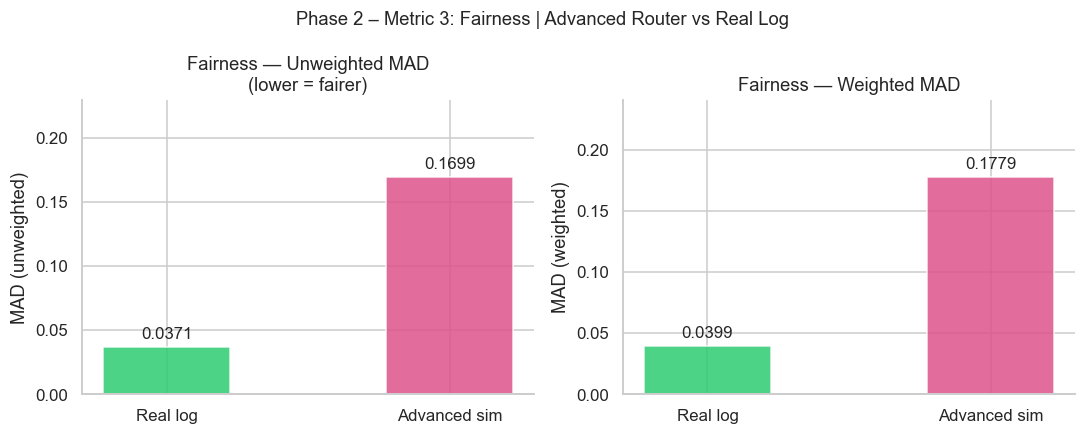

MAD  — Real: 0.0371   Advanced: 0.1699
wMAD — Real: 0.0399  Advanced: 0.1779


In [42]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
labels_p2f = ['Real log', 'Advanced sim']
colors_p2f  = [REAL_COLOR, COLORS['advanced']]

ax = axes[0]
bars = ax.bar(labels_p2f, [r_mad, a_mad], color=colors_p2f, alpha=0.85, width=0.45)
ax.bar_label(bars, fmt='%.4f', padding=3)
ax.set_ylabel('MAD (unweighted)'); ax.set_title('Fairness — Unweighted MAD\n(lower = fairer)')
ax.set_ylim(0, max(r_mad, a_mad) * 1.35)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

ax2 = axes[1]
bars2 = ax2.bar(labels_p2f, [r_wmad, a_wmad], color=colors_p2f, alpha=0.85, width=0.45)
ax2.bar_label(bars2, fmt='%.4f', padding=3)
ax2.set_ylabel('MAD (weighted)'); ax2.set_title('Fairness — Weighted MAD')
ax2.set_ylim(0, max(r_wmad, a_wmad) * 1.35)
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)

plt.suptitle('Phase 2 – Metric 3: Fairness | Advanced Router vs Real Log', fontsize=12)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'p2_advanced_fairness_vs_real.png', bbox_inches='tight')
plt.show()
print(f"MAD  — Real: {r_mad:.4f}   Advanced: {a_mad:.4f}")
print(f"wMAD — Real: {r_wmad:.4f}  Advanced: {a_wmad:.4f}")


### Metric 4 – Outcome Distribution Fidelity: Advanced Router vs Real Log

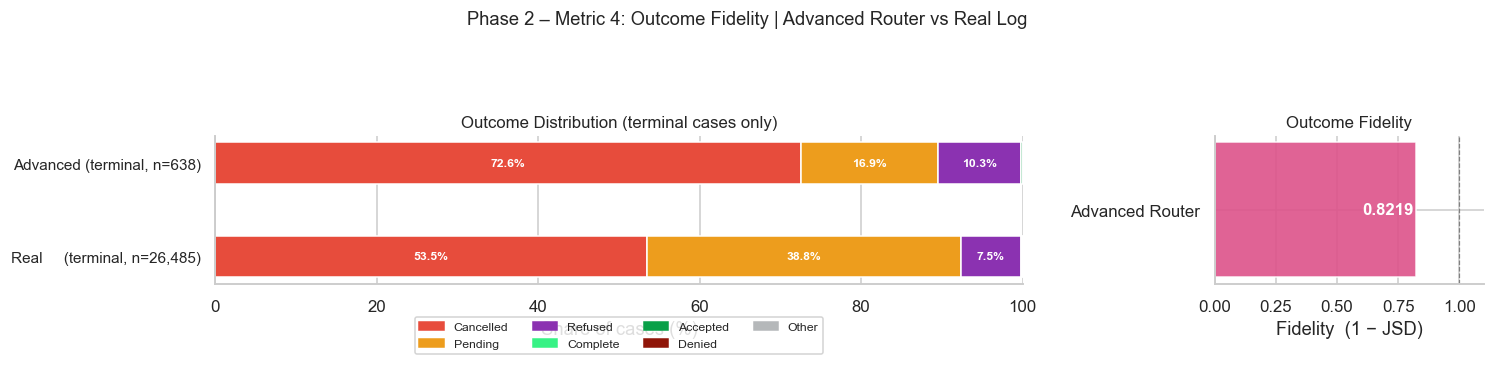

Advanced — JSD: 0.1781   Fidelity: 0.8219


In [43]:
fig, axes = plt.subplots(1, 2, figsize=(14, 3.5), gridspec_kw={'width_ratios': [3, 1]})

rows_p2 = [
    (f'Real     (terminal, n={n_real_terminal:,})',    real_dist_out),
    (f'Advanced (terminal, n={n_adv_terminal:,})', adv_dist_out),
]
ax = axes[0]
bar_h = 0.45
for i, (label, dist) in enumerate(rows_p2):
    left = 0.0
    for cat in OUTCOME_CATEGORIES:
        val = dist[cat] * 100
        ax.barh(i, val, bar_h, left=left, color=OUTCOME_COLORS[cat],
                label=cat if i == 0 else '')
        if val >= 4:
            ax.text(left + val / 2, i, f'{val:.1f}%',
                    ha='center', va='center', fontsize=8, color='white', fontweight='bold')
        left += val
ax.set_yticks(range(len(rows_p2))); ax.set_yticklabels([r[0] for r in rows_p2], fontsize=10)
ax.set_xlabel('Share of cases (%)'); ax.set_xlim(0, 100)
ax.set_title('Outcome Distribution (terminal cases only)', fontsize=11)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
handles = [mpatches.Patch(color=OUTCOME_COLORS[c], label=c) for c in OUTCOME_CATEGORIES]
ax.legend(handles=handles, fontsize=8, ncol=4, loc='upper center',
          bbox_to_anchor=(0.5, -0.18), framealpha=0.85)

ax2 = axes[1]
bars = ax2.barh(['Advanced Router'], [fidelity_a], color=[COLORS['advanced']], alpha=0.9, height=0.4)
for bar, val in zip(bars, [fidelity_a]):
    ax2.text(val - 0.01, bar.get_y() + bar.get_height() / 2,
             f'{val:.4f}', ha='right', va='center', fontsize=11, color='white', fontweight='bold')
ax2.set_xlim(0, 1.1); ax2.axvline(1.0, color='grey', linestyle='--', lw=0.8)
ax2.set_xlabel('Fidelity  (1 − JSD)'); ax2.set_title('Outcome Fidelity', fontsize=11)
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)

plt.suptitle('Phase 2 – Metric 4: Outcome Fidelity | Advanced Router vs Real Log', fontsize=12, y=1.05)
plt.tight_layout(pad=2.0)
plt.savefig(RESULTS_DIR / 'p2_advanced_fidelity_vs_real.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Advanced — JSD: {jsd_a:.4f}   Fidelity: {fidelity_a:.4f}")


### Simulation Configuration

Both simulated logs evaluated in this notebook were produced with the **same fixed infrastructure settings**, varying only the decision routing strategy:

| Component | Setting | Rationale |
|---|---|---|
| **Resource Allocator** | `ADVANCED_GLOBAL` | Global optimal assignment solving — jointly assigns tasks to minimize total cost |
| **Processing Time Model** | QR (`pt_use_qr=True`) | Lower pinball loss than parametric baseline |
| **Availability Schedule** | `availabilities_advanced.csv` | Full realistic shift coverage |
| **Decision Routing – Basic** | `DPManager(mode="basic")` | Probability-based routing from real log |
| **Decision Routing – Advanced** | `DPManager(mode="advanced")` | C4.5 tree trained on real log |
| **Simulation window** | 2016-05-17 → 2016-06-04 | 18 days, ~100 000 events, ~2 000 cases |

The decision routing strategy is the **only independent variable** in this evaluation. Resource allocation and processing times are held constant to isolate the effect of the routing model.

## Summary Dashboard – Basic vs Advanced Router

Consolidating all three metrics to directly compare routing strategies.

In [44]:
summary = pd.DataFrame({
    'Metric': [
        'Avg Cycle Time (h)',
        'Avg Cycle Time (days)',
        'Avg Resource Occupation (%)',
        'Fairness – MAD (unweighted)',
        'Fairness – MAD (weighted)',
        'Outcome Fidelity (1 − JSD)',
    ],
    'Advanced Router': [
        round(advanced_ct.mean(), 2),
        round(advanced_ct.mean() / 24, 3),
        round(advanced_occ['occupation'].mean() * 100, 3),
        round(a_mad, 5),
        round(a_wmad, 5),
        round(fidelity_a, 4),
    ],
})

print('         EVALUATION SUMMARY – ALL FOUR METRICS')
print(summary.to_string(index=False))
print()
print('Note: Cycle Time and Fairness MAD  → lower is better.')
print('      Resource Occupation          → higher is better.')
print('      Outcome Fidelity (1 − JSD)   → higher is better.')

         EVALUATION SUMMARY – ALL FOUR METRICS
                     Metric  Advanced Router
         Avg Cycle Time (h)         12.14000
      Avg Cycle Time (days)          0.50600
Avg Resource Occupation (%)         14.00000
Fairness – MAD (unweighted)          0.16989
  Fairness – MAD (weighted)          0.17791
 Outcome Fidelity (1 − JSD)          0.82190

Note: Cycle Time and Fairness MAD  → lower is better.
      Resource Occupation          → higher is better.
      Outcome Fidelity (1 − JSD)   → higher is better.


In [ ]:
results_df = pd.DataFrame([{
    'Router':                    'Advanced',
    'Avg Cycle Time (h)':        round(advanced_ct.mean(), 4),
    'Median Cycle Time (h)':     round(advanced_ct.median(), 4),
    'Avg Resource Occupation':   round(advanced_occ['occupation'].mean(), 6),
    'Fairness MAD (unweighted)': round(a_mad, 6),
    'Fairness MAD (weighted)':   round(a_wmad, 6),
    'Outcome Fidelity (1-JSD)':  round(fidelity_a, 4),
}])
results_df.to_csv(RESULTS_DIR / 'evaluation_metrics.csv', index=False)
print('Saved results/evaluation_metrics.csv')
print(results_df.to_string(index=False))

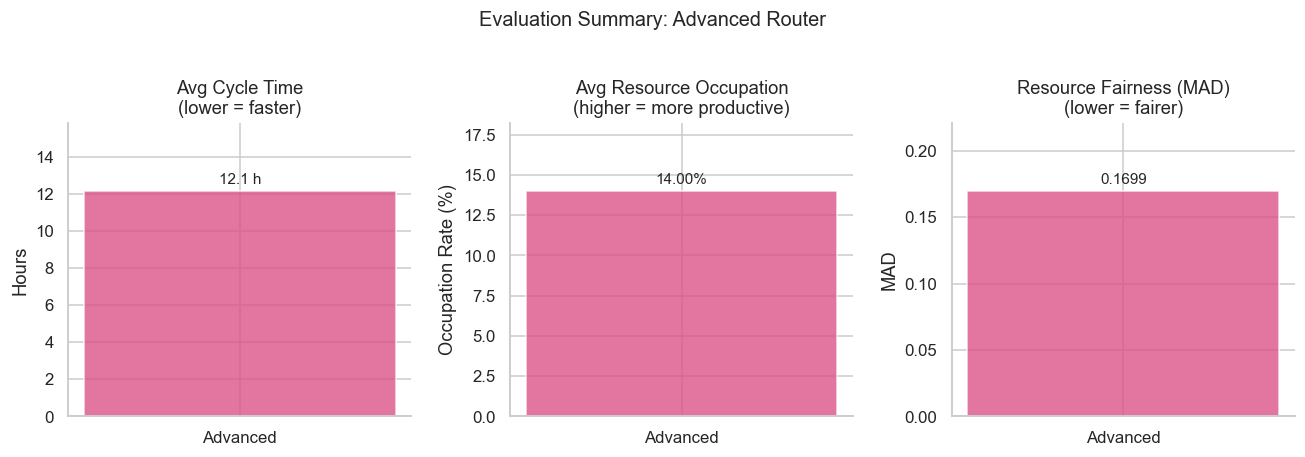

Saved -> results/summary_dashboard.png


In [46]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Cycle Time
ax = axes[0]
vals = [advanced_ct.mean()]
bars = ax.bar(['Advanced'], vals, color=[COLORS['advanced']], alpha=0.8, width=0.4)
ax.bar_label(bars, fmt='%.1f h', padding=3, fontsize=10)
ax.set_ylabel('Hours')
ax.set_title('Avg Cycle Time\n(lower = faster)')
ax.set_ylim(0, max(vals) * 1.3)

# Resource Occupation
ax2 = axes[1]
vals2 = [advanced_occ['occupation'].mean() * 100]
bars2 = ax2.bar(['Advanced'], vals2, color=[COLORS['advanced']], alpha=0.8, width=0.4)
ax2.bar_label(bars2, fmt='%.2f%%', padding=3, fontsize=10)
ax2.set_ylabel('Occupation Rate (%)')
ax2.set_title('Avg Resource Occupation\n(higher = more productive)')
ax2.set_ylim(0, max(vals2) * 1.3)

# Fairness (unweighted MAD)
ax3 = axes[2]
vals3 = [a_mad]
bars3 = ax3.bar(['Advanced'], vals3, color=[COLORS['advanced']], alpha=0.8, width=0.4)
ax3.bar_label(bars3, fmt='%.4f', padding=3, fontsize=10)
ax3.set_ylabel('MAD')
ax3.set_title('Resource Fairness (MAD)\n(lower = fairer)')
ax3.set_ylim(0, max(vals3) * 1.3)

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Evaluation Summary: Advanced Router', fontsize=13, y=1.03)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'summary_dashboard.png', bbox_inches='tight')
plt.show()
print('Saved -> results/summary_dashboard.png')

## Phase 4: All Configs vs Real Log

Compares each allocation config (shortest_queue, advanced_local_d5, advanced_global_d100) against the real BPI 2017 log on all four metrics.

In [47]:
_P4_START = datetime.date(2016, 5, 17)
_P4_END   = datetime.date(2016, 5, 31)   # 14-day window

# Real log reference values for Phase 4
_real_ct_p4    = compute_cycle_times(real_log)
_real_ct_p4_f  = _real_ct_p4[_real_ct_p4 > 2]
_real_work_p4  = compute_working_seconds(real_log)
_real_avail_p4 = compute_available_seconds(avail_df, _P4_START, _P4_END)
_real_occ_p4   = compute_occupation(_real_work_p4, _real_avail_p4)

_real_outcomes_p4 = classify_outcomes(real_log, terminal_filter=True)
_real_dist_p4     = outcome_dist(_real_outcomes_p4)

metric_rows = []

for cfg_name, sim_df in config_logs.items():
    if sim_df.empty:
        print(f"[skip] {cfg_name}: no data")
        continue

    # Metric 1: Cycle Time
    sim_ct   = compute_cycle_times(sim_df)
    sim_ct_f = sim_ct[sim_ct > 2]

    # Metric 2: Resource Occupation
    sim_work = compute_working_seconds(sim_df)
    avail_p4 = compute_available_seconds(avail_df, _P4_START, _P4_END)
    sim_occ  = compute_occupation(sim_work, avail_p4)

    # Metric 3: Fairness MAD
    _, sim_mad, sim_wmad = fairness_metrics(sim_occ["occupation"], sim_occ["available_seconds"])

    # Metric 4: Outcome Fidelity
    sim_outcomes = classify_outcomes(sim_df, terminal_filter=True)
    sim_dist     = outcome_dist(sim_outcomes)
    jsd_val      = jsd_outcomes(_real_dist_p4, sim_dist)
    fidelity     = 1 - jsd_val

    metric_rows.append({
        "Config":           cfg_name,
        "CT Mean (h)":      sim_ct_f.mean(),
        "CT Median (h)":    sim_ct_f.median(),
        "Occ Mean":         sim_occ["occupation"].mean(),
        "Fairness MAD":     sim_mad,
        "Outcome Fidelity": fidelity,
        "N cases":          sim_df["case:concept:name"].nunique(),
    })

# Build summary table with real log row prepended
metrics_df = pd.DataFrame(metric_rows)
real_ref = pd.DataFrame([{
    "Config":           "REAL LOG",
    "CT Mean (h)":      _real_ct_p4_f.mean(),
    "CT Median (h)":    _real_ct_p4_f.median(),
    "Occ Mean":         _real_occ_p4["occupation"].mean(),
    "Fairness MAD":     float("nan"),
    "Outcome Fidelity": 1.0,
    "N cases":          real_log["case:concept:name"].nunique(),
}])
metrics_df = pd.concat([real_ref, metrics_df], ignore_index=True)
metrics_df

,Config,CT Mean (h),CT Median (h),Occ Mean,Fairness MAD,Outcome Fidelity,N cases
0,REAL LOG,527.412900,460.889025,0.655726,NaN,1.000000,31509
1,shortest_queue,29.099594,22.608363,0.538878,0.430329,0.635971,2020
2,advanced_local_d5,18.848426,16.480644,0.407768,0.320725,0.649025,720
3,advanced_global_d100,29.180673,25.034646,0.819007,0.256192,0.641382,1557


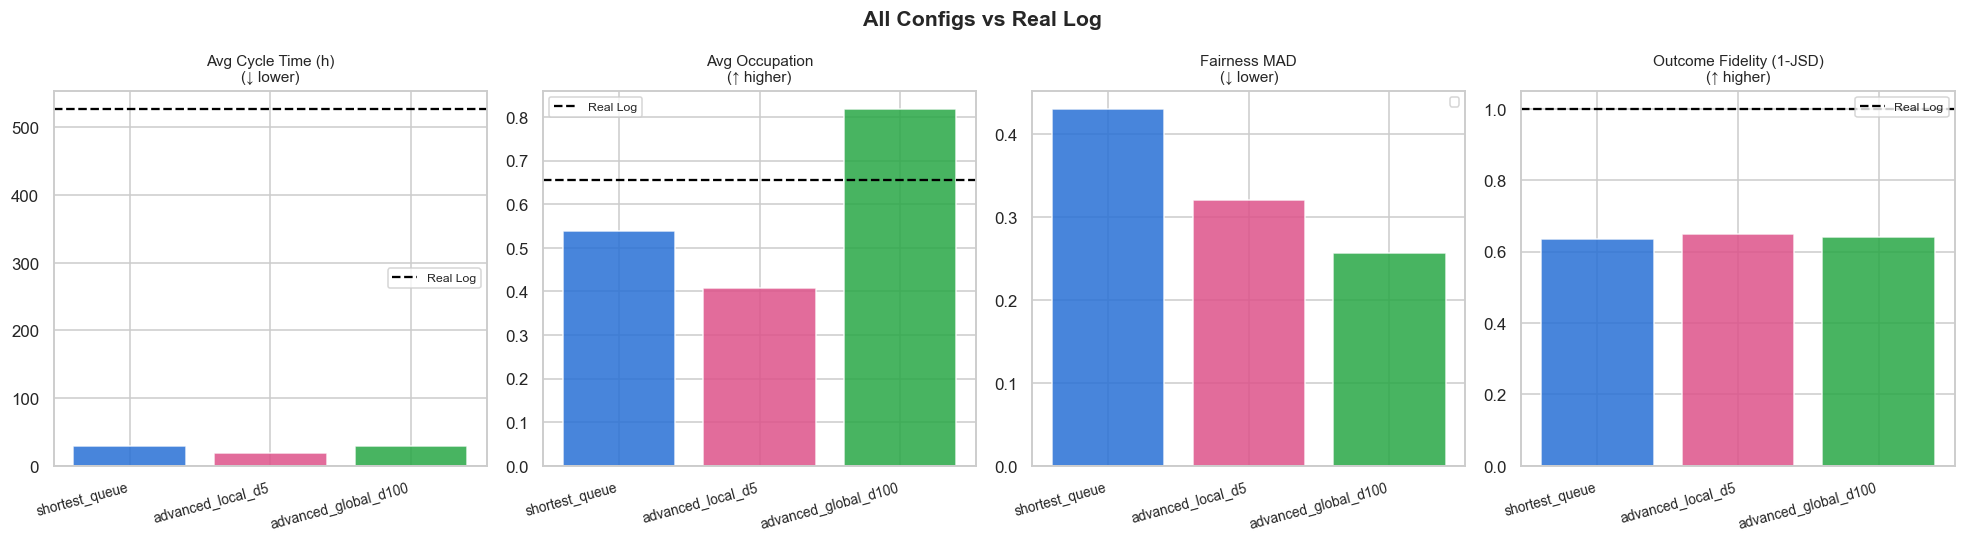

In [48]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle("All Configs vs Real Log", fontsize=14, fontweight='bold')

real_row = metrics_df[metrics_df["Config"] == "REAL LOG"].iloc[0]
sim_rows = metrics_df[metrics_df["Config"] != "REAL LOG"]

cfg_colors = ["#2870D5", "#DD528A", "#28A745"]

for ax, (col, label, better) in zip(axes, [
    ("CT Mean (h)",      "Avg Cycle Time (h)",    "↓ lower"),
    ("Occ Mean",         "Avg Occupation",         "↑ higher"),
    ("Fairness MAD",     "Fairness MAD",           "↓ lower"),
    ("Outcome Fidelity", "Outcome Fidelity (1-JSD)","↑ higher"),
]):
    vals = sim_rows[col].values
    cfgs = sim_rows["Config"].values
    bars = ax.bar(range(len(cfgs)), vals, color=cfg_colors[:len(cfgs)], alpha=0.85, edgecolor='white')
    if col != "Fairness MAD" and not pd.isna(real_row[col]):
        ax.axhline(real_row[col], color='black', linewidth=1.5, linestyle='--', label='Real Log')
    ax.set_xticks(range(len(cfgs)))
    ax.set_xticklabels(cfgs, rotation=15, ha='right', fontsize=9)
    ax.set_title(f"{label}\n({better})", fontsize=10)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "phase4_configs_vs_real.png", dpi=130, bbox_inches='tight')
plt.show()

In [49]:
metrics_df.to_csv(RESULTS_DIR / "evaluation_metrics_vs_real.csv", index=False)
print(f"Saved to {RESULTS_DIR / 'evaluation_metrics_vs_real.csv'}")
metrics_df

Saved to results/evaluation_metrics_vs_real.csv


,Config,CT Mean (h),CT Median (h),Occ Mean,Fairness MAD,Outcome Fidelity,N cases
0,REAL LOG,527.412900,460.889025,0.655726,NaN,1.000000,31509
1,shortest_queue,29.099594,22.608363,0.538878,0.430329,0.635971,2020
2,advanced_local_d5,18.848426,16.480644,0.407768,0.320725,0.649025,720
3,advanced_global_d100,29.180673,25.034646,0.819007,0.256192,0.641382,1557
